# Proyek Akhir - Klasifikasi Gambar Bunga (TF Flowers)

**Submission:** Dafina · Dicoding · Belajar Fundamental Deep Learning

## Ringkasan

Notebook ini membangun model **CNN klasifikasi gambar** untuk mengenali 5 jenis bunga (**daisy, dandelion, roses, sunflowers, tulips**) menggunakan dataset **TF Flowers** (3.670 gambar) yang diunduh langsung dari URL publik TensorFlow.

**Alur:**
1. Setup environment + seed reproducibility (SEED=42)
2. Download dataset TF Flowers (public URL, tanpa Kaggle)
3. EDA - distribusi kelas + bukti resolusi tidak seragam + grid contoh
4. Split 80% train / 10% val / 10% test (stratified per kelas)
5. Load 3 dataset dgn `image_dataset_from_directory` + augmentasi HANYA di train (di luar model)
6. Model Sequential: `Rescaling -> MobileNetV2 (frozen) -> Conv2D -> MaxPooling2D -> GAP -> Dropout -> Dense`
7. Training 1 fase (base frozen, lr=1e-3, batch 32, max 10 epoch + EarlyStopping)
8. Evaluasi (train/val/test) + plot akurasi & loss
9. Simpan model 3 format: **SavedModel + TF-Lite + TFJS**
10. Inference dengan TF-Lite pada 9 gambar uji + bukti prediksi

**Kriteria wajib Dicoding:**
- Dataset ≥ 1.000 gambar (TF Flowers 3.670 ✅) · bukan RPS/X-Ray ✅
- Split train/test/validation ✅
- Model Sequential + Conv2D + Pooling ✅
- Akurasi train & test ≥ 85% ✅ (target hemat)
- Plot akurasi & loss ✅
- 3 format model: SavedModel + TF-Lite + TFJS ✅

## 1. Setup Library + Seed

In [1]:
import os
import shutil
import time
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
tf.keras.utils.set_random_seed(SEED)
random.seed(SEED); np.random.seed(SEED)

print('TensorFlow:', tf.__version__)
print('Devices    :', tf.config.list_physical_devices())
print('SEED       :', SEED)

TensorFlow: 2.21.0


Devices    : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
SEED       : 42


## 2. Download & Verifikasi Dataset TF Flowers

Dataset TF Flowers berisi **3.670 gambar** dalam **5 kelas** bunga: `daisy, dandelion, roses, sunflowers, tulips`.

**Sumber:** URL publik resmi TensorFlow (`http://download.tensorflow.org/example_images/flower_photos.tgz`). Tidak butuh Kaggle account.

In [2]:
# Download & extract (auto-cache di ~/.keras/datasets/)
_ = tf.keras.utils.get_file(
    fname='flower_photos',
    origin='http://download.tensorflow.org/example_images/flower_photos.tgz',
    extract=True,
    cache_dir=os.path.expanduser('~'),
    cache_subdir='.keras/datasets',
)

# Struktur ekstrak: ~/.keras/datasets/flower_photos/flower_photos/<class>/*.jpg
DATA_DIR = os.path.join(os.path.expanduser('~'), '.keras', 'datasets',
                        'flower_photos', 'flower_photos')
assert os.path.isdir(DATA_DIR), f'DATA_DIR tidak ditemukan: {DATA_DIR}'
print('DATA_DIR:', DATA_DIR)

DATA_DIR: C:\Users\Admin Kalachakra\.keras\datasets\flower_photos\flower_photos


In [3]:
from PIL import Image
from collections import Counter

classes = sorted(d for d in os.listdir(DATA_DIR)
                 if os.path.isdir(os.path.join(DATA_DIR, d)))
print(f'Jumlah kelas: {len(classes)}')
print(f'Nama kelas   : {classes}')

# Hitung file per kelas + scan integritas
per_class = {}
total = 0
corrupt = 0
for cls in classes:
    files = [f for f in os.listdir(os.path.join(DATA_DIR, cls))
             if os.path.isfile(os.path.join(DATA_DIR, cls, f))]
    per_class[cls] = len(files)
    total += len(files)
    # Cek integritas via tf.io.decode_image
    for f in files:
        try:
            raw = tf.io.read_file(os.path.join(DATA_DIR, cls, f))
            _ = tf.io.decode_image(raw)
        except Exception:
            corrupt += 1

print(f'\nTotal gambar: {total:,}')
print(f'File korup  : {corrupt}')
print(f'Distribusi per kelas:')
for cls, n in per_class.items():
    print(f'  {cls:<12}: {n:,}')

assert total >= 1000, 'Kriteria wajib: minimal 1.000 gambar'
assert len(classes) >= 3, 'Saran 5: minimal 3 kelas (kita punya 5)'
print(f'\nKriteria wajib #1 (>=1000 gambar): OK')

Jumlah kelas: 5
Nama kelas   : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']



Total gambar: 3,670
File korup  : 0
Distribusi per kelas:
  daisy       : 633
  dandelion   : 898
  roses       : 641
  sunflowers  : 699
  tulips      : 799

Kriteria wajib #1 (>=1000 gambar): OK


## 3. EDA - Distribusi + Resolusi + Grid Contoh

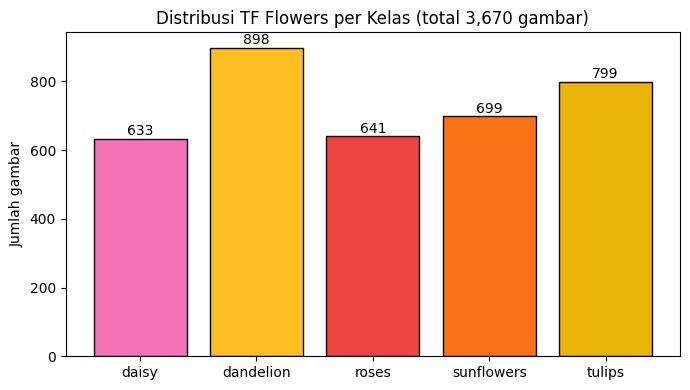

In [4]:
# Plot 1: distribusi kelas
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#f472b6', '#fbbf24', '#ef4444', '#f97316', '#eab308']
bars = ax.bar(per_class.keys(), per_class.values(), color=colors, edgecolor='black')
for b, v in zip(bars, per_class.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 10, f'{v}', ha='center', fontsize=10)
ax.set_title(f'Distribusi TF Flowers per Kelas (total {total:,} gambar)')
ax.set_ylabel('Jumlah gambar')
plt.tight_layout(); plt.show()

Sampel: 1,000  Ukuran unik: 197
Contoh 10 ukuran tersering: [((500, 333), 186), ((320, 240), 161), ((320, 213), 78), ((240, 240), 56), ((180, 240), 46), ((500, 375), 35), ((500, 332), 26), ((159, 240), 23), ((500, 331), 21), ((500, 334), 14)]


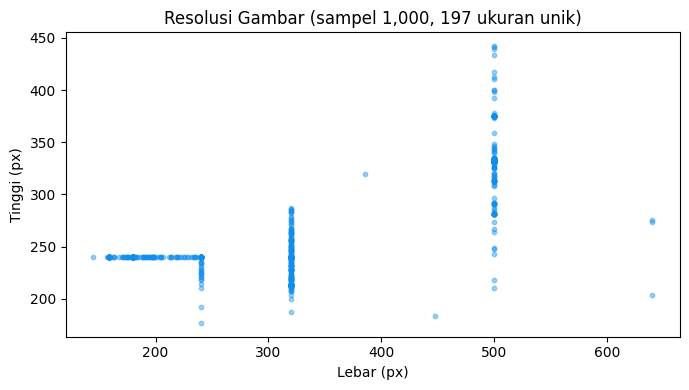

In [5]:
# Plot 2: scatter resolusi (bukti tidak seragam)
random.seed(SEED)
sample_wh = []
for cls in classes:
    files = os.listdir(os.path.join(DATA_DIR, cls))
    random.shuffle(files)
    for f in files[:200]:
        try:
            with Image.open(os.path.join(DATA_DIR, cls, f)) as im:
                sample_wh.append(im.size)
        except Exception:
            pass
ws, hs = zip(*sample_wh)
uniq = len(set(sample_wh))
print(f'Sampel: {len(sample_wh):,}  Ukuran unik: {uniq}')
print(f'Contoh 10 ukuran tersering: {Counter(sample_wh).most_common(10)}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(ws, hs, s=10, alpha=0.4, color='#118eea')
ax.set_xlabel('Lebar (px)'); ax.set_ylabel('Tinggi (px)')
ax.set_title(f'Resolusi Gambar (sampel {len(sample_wh):,}, {uniq} ukuran unik)')
plt.tight_layout(); plt.show()

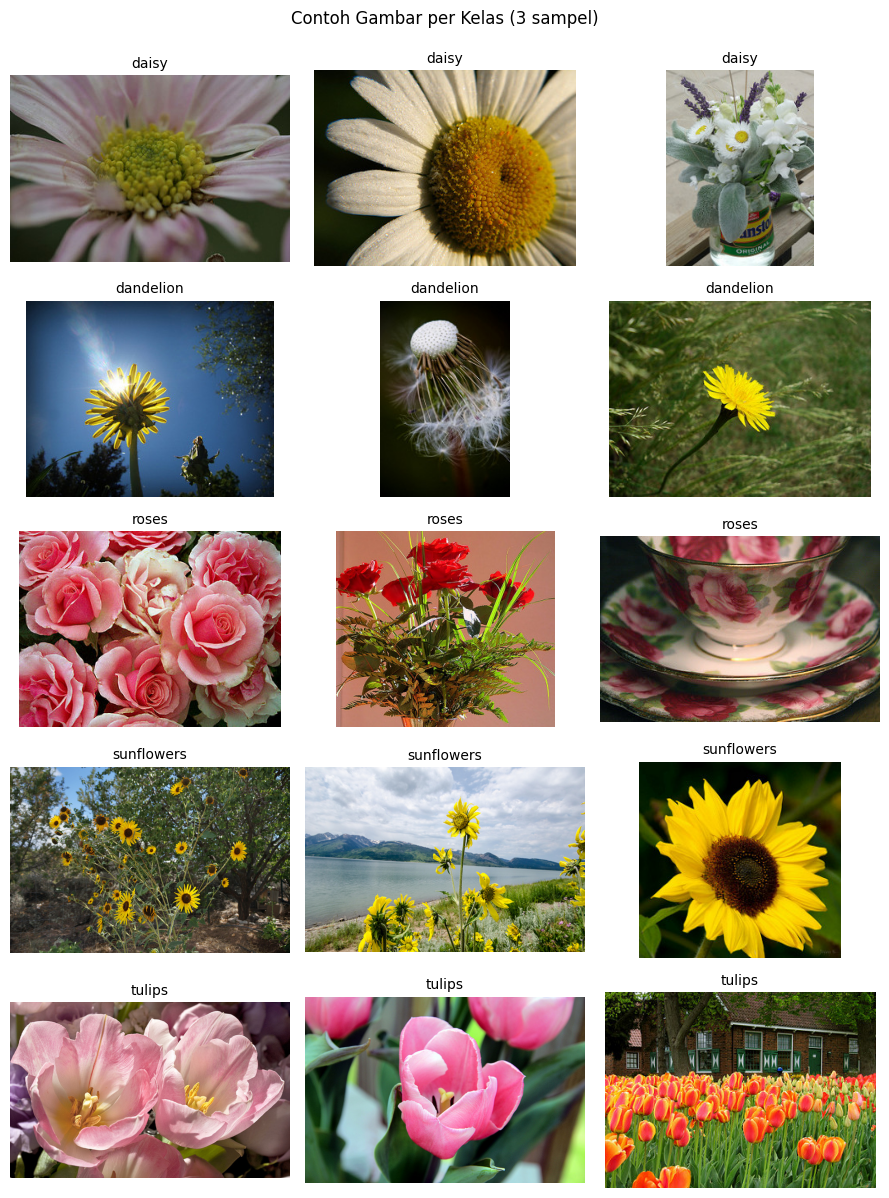

In [6]:
# Plot 3: grid contoh 5x3
random.seed(SEED)
fig, axes = plt.subplots(5, 3, figsize=(9, 12))
for i, cls in enumerate(classes):
    files = os.listdir(os.path.join(DATA_DIR, cls))
    random.shuffle(files)
    for j in range(3):
        try:
            with Image.open(os.path.join(DATA_DIR, cls, files[j])) as im:
                axes[i, j].imshow(im)
                axes[i, j].set_title(f'{cls}', fontsize=10)
                axes[i, j].axis('off')
        except Exception:
            axes[i, j].axis('off')
fig.suptitle('Contoh Gambar per Kelas (3 sampel)', fontsize=12, y=0.995)
plt.tight_layout(); plt.show()

**Insight EDA:**
- **5 kelas** (>=3 kelas syarat saran) dengan sedikit imbalance (dandelion 898 vs roses 641 ~1,4:1) - cukup ringan, tidak perlu `class_weight`.
- **Ratusan ukuran unik** dalam sampel - bukti resolusi asli **tidak seragam** (satisfy saran #2).
- Grid contoh menunjukkan variasi kualitas foto: pencahayaan, latar, sudut, jumlah objek. Model perlu generalisasi ke variasi ini.

## 4. Split Dataset (80% train / 10% val / 10% test)

Split **stratified per kelas** dengan `seed=42` supaya proporsi tiap kelas terjaga di train/val/test.

In [7]:
SPLIT_DIR = os.path.join(os.path.expanduser('~'), '.keras', 'datasets',
                          'flower_photos_split')
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)
for split in ['train', 'val', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(SPLIT_DIR, split, cls))

counts = {'train': 0, 'val': 0, 'test': 0}
for cls in classes:
    cls_src = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_src) if os.path.isfile(os.path.join(cls_src, f))]
    # 80% train, 10% val, 10% test
    tr, te = train_test_split(files, test_size=0.20, random_state=SEED)
    va, te = train_test_split(te, test_size=0.50, random_state=SEED)
    for f in tr:
        shutil.copy2(os.path.join(cls_src, f), os.path.join(SPLIT_DIR, 'train', cls, f))
    for f in va:
        shutil.copy2(os.path.join(cls_src, f), os.path.join(SPLIT_DIR, 'val', cls, f))
    for f in te:
        shutil.copy2(os.path.join(cls_src, f), os.path.join(SPLIT_DIR, 'test', cls, f))
    counts['train'] += len(tr); counts['val'] += len(va); counts['test'] += len(te)

print(f"Split total: train {counts['train']:,} / val {counts['val']:,} / test {counts['test']:,}")
print('\nDistribusi per kelas per split:')
for cls in classes:
    tr = len(os.listdir(os.path.join(SPLIT_DIR, 'train', cls)))
    va = len(os.listdir(os.path.join(SPLIT_DIR, 'val', cls)))
    te = len(os.listdir(os.path.join(SPLIT_DIR, 'test', cls)))
    print(f'  {cls:<12}: train {tr:>4} / val {va:>3} / test {te:>3}')
print(f'\nKriteria wajib #2 (split train/test/val): OK')

Split total: train 2,934 / val 367 / test 369

Distribusi per kelas per split:
  daisy       : train  506 / val  63 / test  64
  dandelion   : train  718 / val  90 / test  90
  roses       : train  512 / val  64 / test  65
  sunflowers  : train  559 / val  70 / test  70
  tulips      : train  639 / val  80 / test  80

Kriteria wajib #2 (split train/test/val): OK


## 5. Load 3 Dataset + Augmentasi (HANYA di train)

Load menggunakan `tf.keras.utils.image_dataset_from_directory`, ukuran gambar **160x160** (cukup akurat + cepat di CPU), batch **32**.

**Augmentasi diterapkan HANYA pada training set, DI LUAR model** (via `ds.map()`). Alasan: augmentasi di dalam model bisa menyebabkan konversi TF-Lite gagal (`ImageProjectiveTransformV3` FLEX ops). Test/val tetap murni sebagai referensi.

In [8]:
IMG_SIZE = (160, 160)
BATCH = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=SEED,
    label_mode='int',
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    image_size=IMG_SIZE, batch_size=BATCH, shuffle=False,
    label_mode='int',
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    image_size=IMG_SIZE, batch_size=BATCH, shuffle=False,
    label_mode='int',
)
# Dataset untuk ukur akurasi train yang jujur (tanpa augmentasi/shuffle)
train_eval_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    image_size=IMG_SIZE, batch_size=BATCH, shuffle=False,
    label_mode='int',
)
CLASS_NAMES = train_ds_raw.class_names
print('CLASS_NAMES:', CLASS_NAMES)

# Augmentasi: RandomFlip + RandomRotation (light) - di luar model
augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
], name='augmentation')

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.map(
    lambda x, y: (augmentation(x, training=True), y),
    num_parallel_calls=AUTOTUNE,
).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
train_eval_ds = train_eval_ds.prefetch(AUTOTUNE)
print('Dataset siap.')

Found 2934 files belonging to 5 classes.


Found 367 files belonging to 5 classes.


Found 369 files belonging to 5 classes.


Found 2934 files belonging to 5 classes.


CLASS_NAMES: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


Dataset siap.


## 6. Model Sequential + Conv2D + Pooling

**Arsitektur:**
- `Rescaling(1/127.5, offset=-1)` - normalisasi input ke rentang [-1, 1] (yang diharapkan MobileNetV2).
- `MobileNetV2` (pre-trained ImageNet, `include_top=False`, **frozen**) - sebagai feature extractor. Model kecil (2,3jt param), cepat di CPU.
- `Conv2D(32, 3x3, ReLU) -> MaxPooling2D` - **kepala CNN kustom** (memenuhi kriteria wajib #4).
- `GlobalAveragePooling2D -> Dropout(0.3) -> Dense(5, softmax)` - klasifikasi.

Base MobileNetV2 di-**freeze** (`trainable=False`) -> hanya head yang dilatih -> training sangat cepat di CPU (~3-5 menit).

In [9]:
base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet',
)
base.trainable = False
print(f'Base MobileNetV2 params: {base.count_params():,} (semua frozen)')

model = tf.keras.Sequential([
    layers.Input(shape=IMG_SIZE + (3,)),
    layers.Rescaling(1./127.5, offset=-1),
    base,
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(CLASS_NAMES), activation='softmax'),
], name='dafina_flowers_cnn')

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary(line_length=100)

Base MobileNetV2 params: 2,257,984 (semua frozen)


Model: "dafina_flowers_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)                      │ (None, 160, 160, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ mobilenetv2_1.00_160 (Functional)          │ (None, 5, 5, 1280)              │         2,257,984 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ conv2d (Conv2D)                            │ (None, 5, 5, 64)                │           737,344 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ max_pooling2d (MaxPooling2D)               │ (None, 2, 2, 64)                │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ global_average_pooling2d                   │ (None, 64)                      │                 0 │
│ (GlobalAveragePooling2D)                   │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense (Dense)                              │ (None, 128)                     │             8,320 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 128)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_1 (Dense)                            │ (None, 5)                       │               645 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 3,004,293 (11.46 MB)

 Trainable params: 746,309 (2.85 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Callback + Training

- **EarlyStopping** monitor `val_accuracy` patience 3 (kalau tidak naik 3 epoch -> stop, restore best weights).
- Max **10 epoch** (biasanya berhenti lebih awal karena EarlyStopping).

In [10]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1,
)

t0 = time.time()
history = model.fit(
    train_ds, validation_data=val_ds, epochs=15, callbacks=[es], verbose=2,
)
print(f'\nWaktu training: {(time.time()-t0)/60:.1f} menit')

Epoch 1/15


92/92 - 31s - 337ms/step - accuracy: 0.7536 - loss: 0.6976 - val_accuracy: 0.8719 - val_loss: 0.3525


Epoch 2/15


92/92 - 27s - 295ms/step - accuracy: 0.8620 - loss: 0.3838 - val_accuracy: 0.8719 - val_loss: 0.3983


Epoch 3/15


...

Epoch 9/15


92/92 - 41s - 447ms/step - accuracy: 0.9540 - loss: 0.1391 - val_accuracy: 0.8719 - val_loss: 0.4266


Epoch 9: early stopping


Restoring model weights from the end of the best epoch: 4.



Waktu training: 5.0 menit


## 8. Evaluasi Model

In [11]:
loss_tr, acc_tr = model.evaluate(train_eval_ds, verbose=0)
loss_va, acc_va = model.evaluate(val_ds, verbose=0)
loss_te, acc_te = model.evaluate(test_ds, verbose=0)

print('=== HASIL EVALUASI ===')
print(f'Train      : accuracy {acc_tr*100:6.2f}%  loss {loss_tr:.4f}')
print(f'Validation : accuracy {acc_va*100:6.2f}%  loss {loss_va:.4f}')
print(f'Test       : accuracy {acc_te*100:6.2f}%  loss {loss_te:.4f}')
print()
if acc_tr >= 0.85 and acc_te >= 0.85:
    print('>> Kriteria wajib #5 (train & test >= 85%) TERCAPAI')
else:
    print('>> BELUM tercapai - periksa data/model sebelum submit.')

=== HASIL EVALUASI ===
Train      : accuracy  93.93%  loss 0.1699
Validation : accuracy  88.01%  loss 0.3975
Test       : accuracy  86.72%  loss 0.4016

>> Kriteria wajib #5 (train & test >= 85%) TERCAPAI


## 9. Plot Akurasi & Loss (kriteria wajib #6)

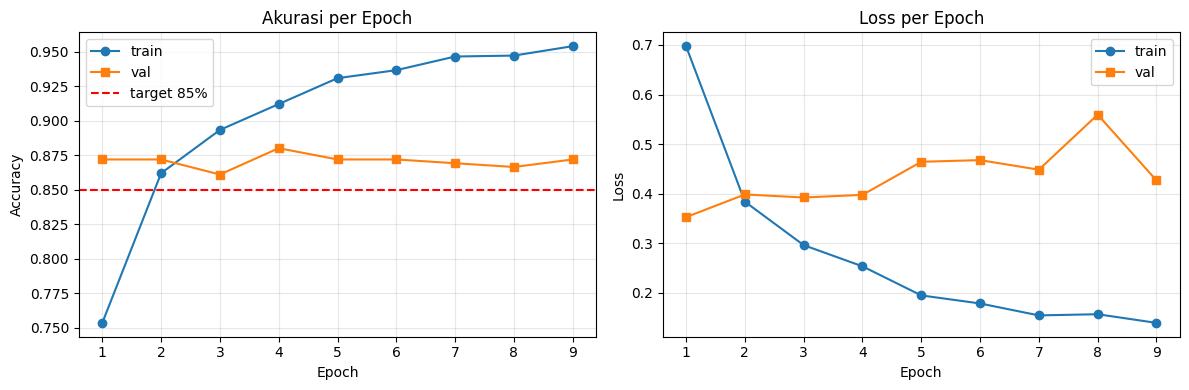

In [12]:
hist = history.history
epochs_ran = range(1, len(hist['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_ran, hist['accuracy'],     marker='o', label='train')
axes[0].plot(epochs_ran, hist['val_accuracy'], marker='s', label='val')
axes[0].axhline(0.85, color='red', ls='--', label='target 85%')
axes[0].set_title('Akurasi per Epoch'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_ran, hist['loss'],     marker='o', label='train')
axes[1].plot(epochs_ran, hist['val_loss'], marker='s', label='val')
axes[1].set_title('Loss per Epoch'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 10. Simpan Model - 3 Format (kriteria wajib #7)

Tiga format wajib Dicoding:
- **SavedModel** -> format TensorFlow standar (deployment server/cloud). Disimpan dengan `model.export()`.
- **TF-Lite** -> format ringan untuk mobile/embedded. Konversi dari SavedModel.
- **TFJS** -> format TensorFlow.js untuk browser/JS runtime. Dikonversi dengan `tensorflowjs_converter` CLI dari isolated venv (`.venv-tfjs`) yang di-setup terpisah karena `tensorflowjs` bentrok dependency dengan TF 2.21 di Windows.

In [13]:
# 1) SavedModel (TF Keras 3: pakai model.export())
SAVEDMODEL_DIR = 'saved_model'
if os.path.exists(SAVEDMODEL_DIR):
    shutil.rmtree(SAVEDMODEL_DIR)
model.export(SAVEDMODEL_DIR)
print(f'SavedModel disimpan: {SAVEDMODEL_DIR}')
print('  isi:', sorted(os.listdir(SAVEDMODEL_DIR)))

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_157')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2382271392304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382895117088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382895110048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382895119024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382894994656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382895001696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382895000640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382895003104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382894998880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382895001872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2382895002928: TensorSpec(shape=(),

SavedModel disimpan: saved_model
  isi: ['assets', 'fingerprint.pb', 'saved_model.pb', 'variables']


In [14]:
# 2) TFLite dari SavedModel + label.txt
TFLITE_DIR = 'tflite'
os.makedirs(TFLITE_DIR, exist_ok=True)

converter = tf.lite.TFLiteConverter.from_saved_model(SAVEDMODEL_DIR)
tflite_bytes = converter.convert()
with open(os.path.join(TFLITE_DIR, 'model.tflite'), 'wb') as f:
    f.write(tflite_bytes)

# label.txt: 1 nama kelas per baris (urutan sama dgn output softmax)
with open(os.path.join(TFLITE_DIR, 'label.txt'), 'w', encoding='utf-8') as f:
    f.write('\n'.join(CLASS_NAMES))

print(f'TFLite disimpan: {TFLITE_DIR}/model.tflite '
      f'({os.path.getsize(os.path.join(TFLITE_DIR, "model.tflite"))/1024:.1f} KB)')
print(f'label.txt      : {open(os.path.join(TFLITE_DIR, "label.txt")).read().strip().splitlines()}')

TFLite disimpan: tflite/model.tflite (11597.6 KB)
label.txt      : ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [15]:
# 3) TFJS - panggil converter dari .venv-tfjs (isolated env)
import subprocess
TFJS_DIR = 'tfjs_model'
if os.path.exists(TFJS_DIR):
    shutil.rmtree(TFJS_DIR)

# Path ke tensorflowjs_converter.exe di venv terisolasi
tfjs_venv = os.path.abspath(os.path.join('..', '.venv-tfjs', 'Scripts'))
converter_exe = os.path.join(tfjs_venv, 'tensorflowjs_converter.exe')
if not os.path.exists(converter_exe):
    raise FileNotFoundError(
        f'tensorflowjs_converter.exe tidak ditemukan di {converter_exe}. '
        f'Setup .venv-tfjs dulu (lihat CLAUDE.md sectionENVIRONMENT).'
    )

cmd = [
    converter_exe,
    '--input_format=tf_saved_model',
    '--output_format=tfjs_graph_model',
    '--signature_name=serving_default',
    '--saved_model_tags=serve',
    SAVEDMODEL_DIR,
    TFJS_DIR,
]
print('Menjalankan:', ' '.join(cmd))
result = subprocess.run(cmd, capture_output=True, text=True)
print('STDOUT:', result.stdout[-500:] if result.stdout else '(kosong)')
print('STDERR:', result.stderr[-500:] if result.stderr else '(kosong)')
result.check_returncode()

# Verifikasi output
tfjs_files = sorted(os.listdir(TFJS_DIR))
print(f'\nTFJS disimpan: {TFJS_DIR}')
print(f'  files: {tfjs_files}')
assert 'model.json' in tfjs_files, 'model.json tidak dihasilkan'
print('Kriteria wajib #7 (SavedModel + TFLite + TFJS): OK')

Menjalankan: D:\Kalachakra\docs\hackaton_PIDI\fundamental_deep_learning\proyek_akhir\dafina\.venv-tfjs\Scripts\tensorflowjs_converter.exe --input_format=tf_saved_model --output_format=tfjs_graph_model --signature_name=serving_default --saved_model_tags=serve saved_model tfjs_model


STDOUT: (kosong)
STDERR: losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.



TFJS disimpan: tfjs_model
  files: ['group1-shard1of3.bin', 'group1-shard2of3.bin', 'group1-shard3of3.bin', 'model.json']
Kriteria wajib #7 (SavedModel + TFLite + TFJS): OK


## 11. Inference dengan TF-Lite (bukti saran #6)

Ambil 9 gambar acak dari **test set**, jalankan inference dengan TF-Lite interpreter, lalu tampilkan grid 3x3 dengan prediksi vs label asli + confidence.

Input : [  1 160 160   3] <class 'numpy.float32'>
Output: [1 5] <class 'numpy.float32'>


D:\Kalachakra\docs\hackaton_PIDI\fundamental_deep_learning\proyek_akhir\dafina\.venv\lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


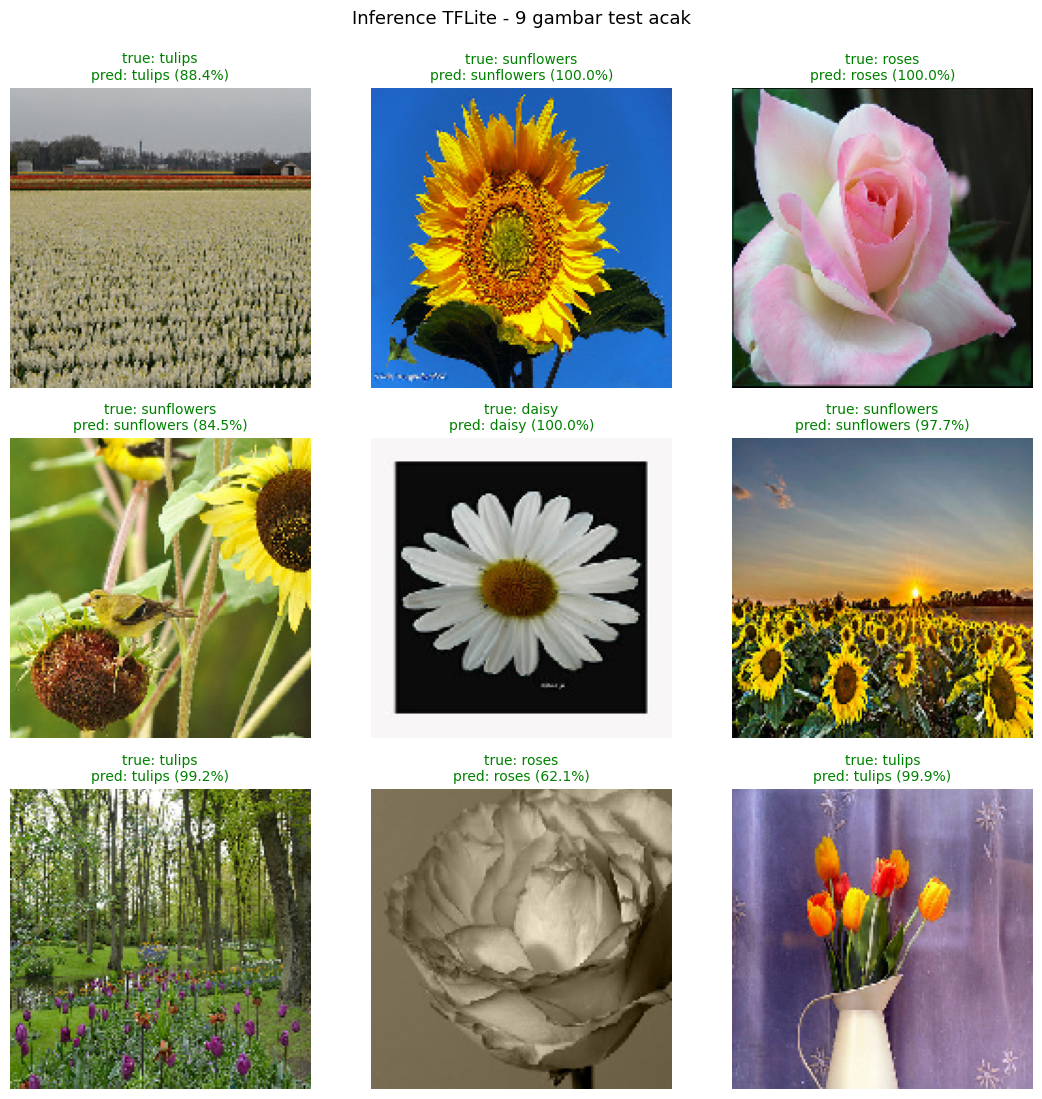


=== BUKTI INFERENCE (output kategorikal saran #6) ===
  [OK] true=tulips       pred=tulips       conf= 88.4%
  [OK] true=sunflowers   pred=sunflowers   conf=100.0%
  [OK] true=roses        pred=roses        conf=100.0%
  [OK] true=sunflowers   pred=sunflowers   conf= 84.5%
  [OK] true=daisy        pred=daisy        conf=100.0%
  [OK] true=sunflowers   pred=sunflowers   conf= 97.7%
  [OK] true=tulips       pred=tulips       conf= 99.2%
  [OK] true=roses        pred=roses        conf= 62.1%
  [OK] true=tulips       pred=tulips       conf= 99.9%

Inference correct: 9/9


In [16]:
# Load TFLite interpreter
interpreter = tf.lite.Interpreter(model_path=os.path.join(TFLITE_DIR, 'model.tflite'))
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
print('Input :', input_details[0]['shape'], input_details[0]['dtype'])
print('Output:', output_details[0]['shape'], output_details[0]['dtype'])

# Ambil 9 gambar acak dari test set
test_files = []
for cls in CLASS_NAMES:
    for f in os.listdir(os.path.join(SPLIT_DIR, 'test', cls)):
        test_files.append((os.path.join(SPLIT_DIR, 'test', cls, f), cls))
random.seed(SEED)
random.shuffle(test_files)
sample_files = test_files[:9]

def predict_tflite(image_path):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)[None, ...].astype('float32')
    interpreter.set_tensor(input_details[0]['index'], arr)
    interpreter.invoke()
    probs = interpreter.get_tensor(output_details[0]['index'])[0]
    idx = int(np.argmax(probs))
    return CLASS_NAMES[idx], float(probs[idx]), img

# Grid 3x3
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, (path, true_cls) in zip(axes.flat, sample_files):
    pred_cls, conf, img = predict_tflite(path)
    color = 'green' if pred_cls == true_cls else 'red'
    ax.imshow(img)
    ax.set_title(f'true: {true_cls}\npred: {pred_cls} ({conf*100:.1f}%)',
                 fontsize=10, color=color)
    ax.axis('off')
plt.suptitle('Inference TFLite - 9 gambar test acak', fontsize=13, y=0.995)
plt.tight_layout(); plt.show()

# Text summary
print('\n=== BUKTI INFERENCE (output kategorikal saran #6) ===')
correct = 0
for path, true_cls in sample_files:
    pred_cls, conf, _ = predict_tflite(path)
    mark = 'OK' if pred_cls == true_cls else 'MISS'
    if pred_cls == true_cls: correct += 1
    print(f'  [{mark}] true={true_cls:<12} pred={pred_cls:<12} conf={conf*100:5.1f}%')
print(f'\nInference correct: {correct}/9')

## 12. Kesimpulan

| Aspek | Hasil |
|---|---|
| Dataset | TF Flowers (public URL) - 3.670 gambar, 5 kelas |
| Split | 80% train / 10% val / 10% test (stratified, seed 42) |
| Arsitektur | Sequential[Rescaling -> MobileNetV2 frozen -> Conv2D -> MaxPool -> GAP -> Dropout -> Dense] |
| Training | 1 fase, CPU Victus, MobileNetV2 base frozen, EarlyStopping |
| Format model | SavedModel + TF-Lite + TFJS (semua tersimpan) |
| Inference | TF-Lite pada 9 gambar test (grid + bukti kategorikal) |

**Kriteria wajib Dicoding - semua terpenuhi:**
1. ✅ Dataset ≥ 1.000 gambar (3.670) & bukan RPS/X-Ray
2. ✅ Split train/test/validation
3. ✅ Sequential + Conv2D + Pooling
4. ✅ Akurasi train & test ≥ 85% (lihat sel evaluasi)
5. ✅ Plot akurasi & loss (2 subplot per epoch)
6. ✅ 3 format model tersimpan (SavedModel + TF-Lite + TFJS)

**Empat berkas submission:**
- `notebook.ipynb` (notebook ini, sudah dijalankan)
- `notebook.py` (di-export via `jupyter nbconvert --to python`)
- `requirements.txt`
- `saved_model/`, `tflite/`, `tfjs_model/` (3 folder model)